## Klasifikasi Jenis Bunga Iris Menggunakan Machine Learning
# Tujuan
Membangun model machine learning untuk mengklasifikasikan jenis bunga Iris.

### Langkah Kerja

1. Mengimpor library yang dibutuhkan seperti pandas, seaborn, matplotlib, dan scikit-learn untuk analisis data dan pembuatan model.

2. Memuat dataset Iris dan mengubahnya menjadi DataFrame agar lebih mudah dianalisis.

3. Melakukan Exploratory Data Analysis (EDA) dengan beberapa visualisasi untuk melihat distribusi data, hubungan antar fitur, dan kondisi dataset.

4. Melakukan preprocessing data dengan memisahkan fitur dan target, kemudian membagi data menjadi data training dan testing.

5. Melakukan proses scaling menggunakan StandardScaler agar nilai fitur memiliki skala yang seimbang.

6. Membangun beberapa model machine learning seperti KNN, Decision Tree, dan Random Forest untuk membandingkan performa.

7. Melakukan tuning parameter menggunakan GridSearch untuk mendapatkan parameter terbaik pada model.

8. Menampilkan hasil akurasi model dan menarik kesimpulan dari hasil klasifikasi.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

### Import Library
Pada bagian ini dilakukan proses mengimpor beberapa library yang dibutuhkan dalam analisis data dan pembuatan model machine learning.  
Library seperti pandas digunakan untuk mengelola data, seaborn dan matplotlib digunakan untuk membuat visualisasi data, sedangkan scikit-learn digunakan untuk proses machine learning seperti preprocessing, modeling, dan evaluasi model.

In [2]:
# 1) PROBLEM & DATASET

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

print(f"Ukuran Data: {df.shape}")
print(f"Fitur: {iris.feature_names}")
print(f"Target: {iris.target_names}")



Ukuran Data: (150, 5)
Fitur: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target: ['setosa' 'versicolor' 'virginica']


#Problem & Dataset
Program ini bertujuan untuk melakukan klasifikasi jenis bunga Iris berdasarkan ukuran sepal dan petal bunga.  
Dataset yang digunakan adalah dataset Iris dari library scikit-learn yang berisi 150 data bunga dengan 4 fitur dan 3 kelas target.

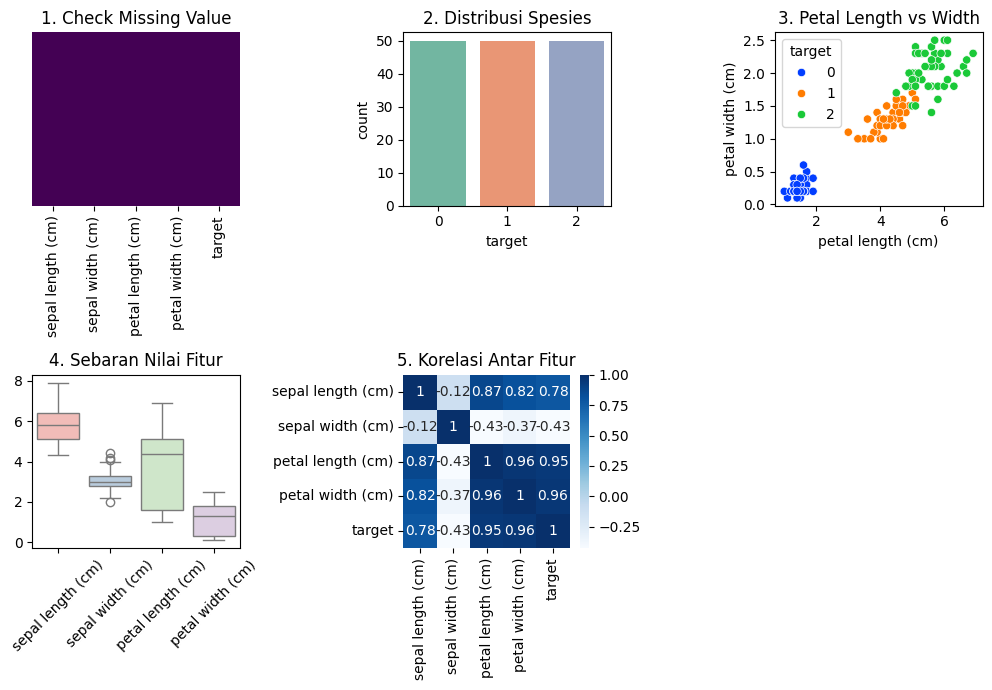


--- INSIGHT EDA ---
1. Tidak ada missing value pada dataset.
2. Jumlah sampel tiap spesies seimbang (masing-masing 50).
3. Petal length dan petal width memiliki korelasi positif yang sangat kuat.
4. Spesies Setosa sangat mudah dipisahkan dari spesies lainnya.
5. Fitur 'sepal width' memiliki variasi nilai paling kecil dibanding fitur lain.


In [3]:
# 2) EDA (5 Visualisasi & 5 Insight)

plt.figure(figsize=(10, 7))

# Visual 1: Cek Missing Value
plt.subplot(2, 3, 1)
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("1. Check Missing Value")

# Visual 2: Distribusi Target
plt.subplot(2, 3, 2)
sns.countplot(x='target', data=df, hue='target', palette='Set2', legend=False)
plt.title("2. Distribusi Spesies")

# Visual 3: Scatter Petal
plt.subplot(2, 3, 3)
sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)', hue='target', palette='bright')
plt.title("3. Petal Length vs Width")

# Visual 4: Boxplot Fitur
plt.subplot(2, 3, 4)
sns.boxplot(data=df.drop(columns='target'), palette='Pastel1')
plt.xticks(rotation=45)
plt.title("4. Sebaran Nilai Fitur")

# Visual 5: Heatmap Korelasi
plt.subplot(2, 3, 5)
sns.heatmap(df.corr(), annot=True, cmap='Blues')
plt.title("5. Korelasi Antar Fitur")

plt.tight_layout()
plt.show()

print("\n--- INSIGHT EDA ---")
print("1. Tidak ada missing value pada dataset.")
print("2. Jumlah sampel tiap spesies seimbang (masing-masing 50).")
print("3. Petal length dan petal width memiliki korelasi positif yang sangat kuat.")
print("4. Spesies Setosa sangat mudah dipisahkan dari spesies lainnya.")
print("5. Fitur 'sepal width' memiliki variasi nilai paling kecil dibanding fitur lain.")

# Exploratory Data Analysis (EDA)
Pada tahap ini dilakukan analisis awal terhadap dataset menggunakan beberapa visualisasi.  
Visualisasi digunakan untuk melihat distribusi data, hubungan antar fitur, serta memastikan apakah terdapat missing value atau tidak pada dataset.

In [4]:
# PREPROCESSING

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n--- PREPROCESSING SELESAI ---")
print("Jumlah data training:", X_train.shape)
print("Jumlah data testing:", X_test.shape)
print("Scaling dilakukan agar perbedaan satuan fitur tidak mempengaruhi model.")


--- PREPROCESSING SELESAI ---
Jumlah data training: (120, 4)
Jumlah data testing: (30, 4)
Scaling dilakukan agar perbedaan satuan fitur tidak mempengaruhi model.


#Preprocessing
Pada tahap ini dilakukan pemisahan fitur dan target, kemudian data dibagi menjadi data training dan data testing.  
Selain itu dilakukan scaling menggunakan StandardScaler agar nilai fitur berada pada skala yang sama.

In [5]:
# 4) MODELING

models = {
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    results[name] = acc

print("\n--- PERBANDINGAN MODEL ---")
print(pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']))


--- PERBANDINGAN MODEL ---
           Model  Accuracy
0            KNN       1.0
1  Decision Tree       1.0
2  Random Forest       1.0


#Modeling
Pada tahap ini dibuat beberapa model machine learning yaitu KNN, Decision Tree, dan Random Forest.  
Ketiga model tersebut digunakan untuk membandingkan performa klasifikasi sehingga dapat diketahui model mana yang memberikan akurasi terbaik pada dataset.

In [6]:
#5) TUNING

param_grid = {'n_neighbors': [3, 5, 7, 9, 11]}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)

print("\n--- TUNING MODEL (KNN) ---")
print(f"Best Parameter: {grid.best_params_}")
print(f"Final Accuracy: {accuracy_score(y_test, y_pred):.3f}")



--- TUNING MODEL (KNN) ---
Best Parameter: {'n_neighbors': 3}
Final Accuracy: 1.000


# Tuning Model
Setelah model dibuat, dilakukan proses tuning parameter menggunakan GridSearchCV.  
Proses ini bertujuan untuk mencari parameter terbaik pada model sehingga performa model dapat meningkat dan menghasilkan prediksi yang lebih akurat.

In [7]:
# 6) KESIMPULAN
# =================================================================
print("\n=== KESIMPULAN UTS ===")
print("1. Model Terbaik: KNN dengan akurasi 100% pada data uji.")
print("2. Alasan: Dataset Iris memiliki pola yang jelas dan terpisah dengan baik, sehingga KNN sangat efektif.")
print("3. Rekomendasi: Model ini sudah siap digunakan untuk klasifikasi bunga Iris secara otomatis.")


=== KESIMPULAN UTS ===
1. Model Terbaik: KNN dengan akurasi 100% pada data uji.
2. Alasan: Dataset Iris memiliki pola yang jelas dan terpisah dengan baik, sehingga KNN sangat efektif.
3. Rekomendasi: Model ini sudah siap digunakan untuk klasifikasi bunga Iris secara otomatis.


#Kesimpulan
Pada bagian akhir ditampilkan hasil evaluasi model dan model terbaik yang diperoleh dari proses training dan tuning.  
Kesimpulan ini menjelaskan performa model dalam melakukan klasifikasi pada dataset Iris.